# CE444: Geotechnical Design, Homework Assignment 5


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sy
from icecream import ic

## Problem 1

Solved on paper.

## Problem 2

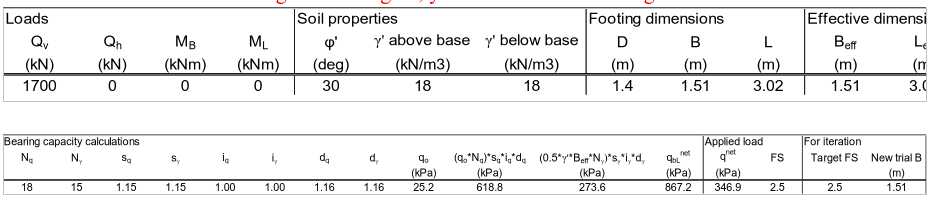

Correct answer: For friction angle of 45 degree, you should be calculating a foundation width of 0.47 m.

In [6]:
phis = np.linspace(30, 45, 16)
phiR = (np.pi/180) * phis
print(phis)
print(phiR)

[30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45.]
[0.52359878 0.54105207 0.55850536 0.57595865 0.59341195 0.61086524
 0.62831853 0.64577182 0.66322512 0.68067841 0.6981317  0.71558499
 0.73303829 0.75049158 0.76794487 0.78539816]


In [8]:
# known values based on variables

gamma_soil = 17 # kN/m^3
z_embed = 1.4 # m
q0 = gamma_soil * z_embed # kPa

i_q = 1
i_gamma = 1

s_q = (1 + (0.1/2) * ((1 + np.sin(np.radians(phis)))/ (1 - np.sin(np.radians(phis)))))
s_gamma = s_q

N_q = ((1 + np.sin(np.radians(phis)) )/ (1 - np.sin(np.radians(phis))) ) * np.exp(np.pi * np.tan(np.radians(phis)))

N_gamma = 1.5* (N_q - 1) * np.tan(np.radians(phis))

ic(gamma_soil, i_q, i_gamma, s_q, s_gamma, N_q, N_gamma)

ic| gamma_soil: 17
    i_q: 1
    i_gamma: 1
    s_q: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                1.29142136])
    s_gamma: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                    1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                    1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                    1.29142136])
    N_q: array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
                 29.43979237,  33.29609149,  37.75249717,  42.91991165,
                 48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
                 85.37362303,  99.01425896, 115.30790234, 134.87384063])
    N_gamma: array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
                     28.77432326,  33.92095008,  40.05337831

(17,
 1,
 1,
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
         29.43979237,  33.29609149,  37.75249717,  42.91991165,
         48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
         85.37362303,  99.01425896, 115.30790234, 134.87384063]),
 array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
         28.77432326,  33.92095008,  40.05337831,  47.38337881,
         56.17434205,  66.75550889,  79.54061156,  95.05245142,
        113.95552712, 137.09966271, 165.57878724, 200.81076094]))

In [ ]:
# solvables 

B = sy.Symbol('B') 

widths = np.zeros(len(phis)) # initializing array

for i in range(len(widths)):
    surcharge_term = q0 * float(N_q[i]) * float(s_q[i]) * i_q * (1 + (0.1*(z_embed/B)*sy.sqrt((1 + sy.sin(phiR[i]))/(1 - sy.sin(phiR[i])))))
    gamma_term = 0.5*18*B*float(N_gamma[i])*float(s_gamma[i])*i_gamma * (1 + (0.1*(z_embed/B)*sy.sqrt((1 + sy.sin(phiR[i]))/(1 - sy.sin(phiR[i])))))
    q_bL_cap = 2125/(B**2)
    widths[i] = sy.solve(surcharge_term + gamma_term - q_bL_cap)[0]

# surcharge_backcalc = q0 * N_q * s_q * i_q * (1 + (0.1*(z_embed/1.51)*np.sqrt((1 + np.sin(phiR)/(1 - np.sin(phiR))))))

ic(widths)
# ic(surcharge_backcalc)

ic| widths: array([1.56832533, 1.47269123, 1.38112563, 1.29341384, 1.20936196,
                   1.12879504, 1.05155543, 0.97750148, 0.9065064 , 0.83845738,
                   0.77325498, 0.7108126 , 0.65105634, 0.59392494, 0.53937003,
                   0.48735663])
ic| surcharge_backcalc: array([ 569.67538943,  643.29288892,  728.10083334,  826.1058614 ,
                                939.73415096, 1071.93227709, 1226.29561213, 1407.23272544,
                               1620.17713761, 1871.86177969, 2170.67706272, 2527.14124554,
                               2954.52278652, 3469.6700403 , 4094.12621307, 4855.64024805])


array([ 569.67538943,  643.29288892,  728.10083334,  826.1058614 ,
        939.73415096, 1071.93227709, 1226.29561213, 1407.23272544,
       1620.17713761, 1871.86177969, 2170.67706272, 2527.14124554,
       2954.52278652, 3469.6700403 , 4094.12621307, 4855.64024805])

## Problem 3

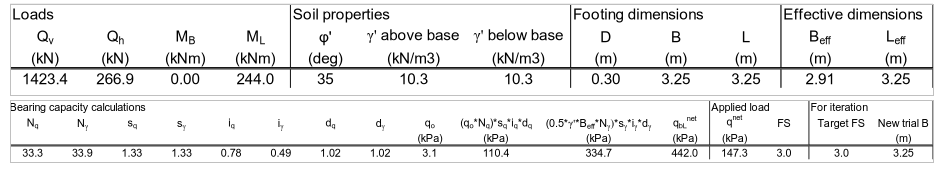